**Trabajo de Sistema de Segmentación Semántica de Tumores Cerebrales mediante Arquitectura U-Net con Backbone ResNet50**

En este caso utilizaremos una arquitectura U-Net para garantizar la precisión espacial de la segmentación, pero reemplazamos su codificador estándar por una ResNet50 preentrenada. Esta estrategia de Transfer Learning nos permitió superar la escasez de datos médicos, acelerar la convergencia del entrenamiento y mejorar la robustez en la detección de características tumorales complejas.

#1. Descarga de la librerias

In [ ]:
#Instalación de Dependencias Críticas
# Forzamos numpy < 2.0 para compatibilidad con TensorFlow actual en Colab
!pip install "numpy<2.0" -U
!pip install pycocotools -q
!pip install kaggle -q

#Importaciones de las librarias necesarias
import os
import glob
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from pycocotools.coco import COCO
from sklearn.metrics import confusion_matrix
from google.colab import files

print(f"TensorFlow versión ok: {tf.__version__}")

✅ Entorno Configurado. TensorFlow versión: 2.19.0


#2. Descargamos la informacion de los datos publicos de Kaggle

In [ ]:
#2.Descargamos la informacion de  Kaggle
if not os.path.exists('/content/dataset'):
    if not os.path.exists('/content/kaggle.json'):
        files.upload()
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    !kaggle datasets download -d pkdarabi/brain-tumor-image-dataset-semantic-segmentation
    with zipfile.ZipFile('brain-tumor-image-dataset-semantic-segmentation.zip', 'r') as zip_ref:
        zip_ref.extractall('/content/dataset')

#Generación de Máscaras para todas las bases
ROOT_DIR = '/content/dataset'

def generate_masks(subset):
    path = os.path.join(ROOT_DIR, subset)
    json_path = os.path.join(path, "_annotations.coco.json")
    mask_dir = os.path.join(path, "masks")
    os.makedirs(mask_dir, exist_ok=True)

    if os.path.exists(json_path):
        coco = COCO(json_path)
        img_ids = coco.getImgIds()
        for img_id in img_ids:
            img_info = coco.loadImgs(img_id)[0]
            ann_ids = coco.getAnnIds(imgIds=img_id)
            anns = coco.loadAnns(ann_ids)
            mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
            for ann in anns:
                mask = np.maximum(mask, coco.annToMask(ann) * 255)
            cv2.imwrite(os.path.join(mask_dir, img_info['file_name'].replace('.jpg', '.png')), mask)

#Aquí procesamos también 'test'
for s in ["train", "valid", "test"]:
    generate_masks(s)

print("las mascaras han generadas para Train, Valid y Test.")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/83.7M [00:00<?, ?B/s]
100% 83.7M/83.7M [00:00<00:00, 1.26GB/s]
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
✅ Máscaras generadas para Train, Valid y Test.


Validamos que esten tanto en train ,valid y test

#3. Normalizamos y Estandarizamos las imagenes

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

def load_optimized(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, [IMG_SIZE, IMG_SIZE])
    mask = tf.cast(mask, tf.float32) / 255.0
    mask = tf.where(mask > 0.5, 1.0, 0.0)
    return img, mask

# 1. Train
train_imgs = sorted(glob.glob(os.path.join(ROOT_DIR, "train", "*.jpg")))
train_msks = sorted(glob.glob(os.path.join(ROOT_DIR, "train", "masks", "*.png")))
train_ds = tf.data.Dataset.from_tensor_slices((train_imgs, train_msks))
train_ds = train_ds.map(load_optimized, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.cache().shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 2. Valid
val_imgs = sorted(glob.glob(os.path.join(ROOT_DIR, "valid", "*.jpg")))
val_msks = sorted(glob.glob(os.path.join(ROOT_DIR, "valid", "masks", "*.png")))
val_ds = tf.data.Dataset.from_tensor_slices((val_imgs, val_msks))
val_ds = val_ds.map(load_optimized, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 3. Test (NUEVO) - No necesita shuffle, solo batch
test_imgs = sorted(glob.glob(os.path.join(ROOT_DIR, "test", "*.jpg")))
test_msks = sorted(glob.glob(os.path.join(ROOT_DIR, "test", "masks", "*.png")))
test_ds = tf.data.Dataset.from_tensor_slices((test_imgs, test_msks))
test_ds = test_ds.map(load_optimized, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("✅ Pipelines listos: Train, Valid y Test.")

✅ Pipelines listos: Train, Valid y Test.


#4.Entrenamos el Modelo

Escogemos los parametros accuracy y el loss como medidas principales para ver el redimiento del entremiento del modelo

In [ ]:
def build_unet_resnet50():
    base = tf.keras.applications.ResNet50(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
    base.trainable = False

    s1 = base.layers[0].output
    s2 = base.get_layer("conv1_relu").output
    s3 = base.get_layer("conv2_block3_out").output
    s4 = base.get_layer("conv3_block4_out").output
    bridge = base.get_layer("conv4_block6_out").output

    def up_block(x, skip, filters):
        x = layers.UpSampling2D((2, 2))(x)
        x = layers.Concatenate()([x, skip])
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        return x

    d1 = up_block(bridge, s4, 256)
    d2 = up_block(d1, s3, 128)
    d3 = up_block(d2, s2, 64)
    d4 = up_block(d3, s1, 32)
    out = layers.Conv2D(1, 1, activation="sigmoid", padding="same")(d4)
    return models.Model(base.input, out)

model = build_unet_resnet50()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar solo si no lo has hecho aún
checkpoint = tf.keras.callbacks.ModelCheckpoint('mejor_modelo.h5', save_best_only=True, monitor='val_loss')
history = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[checkpoint])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 41s/step - accuracy: 0.6550 - loss: 0.7243 

47/47 ━━━━━━━━━━━━━━━━━━━━ 2191s 46s/step - accuracy: 0.6575 - loss: 0.7222 - val_accuracy: 0.6576 - val_loss: 0.5786
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 41s/step - accuracy: 0.9253 - loss: 0.4802 

47/47 ━━━━━━━━━━━━━━━━━━━━ 2169s 46s/step - accuracy: 0.9255 - loss: 0.4794 - val_accuracy: 0.9442 - val_loss: 0.3238
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 40s/step - accuracy: 0.9627 - loss: 0.3332 

47/47 ━━━━━━━━━━━━━━━━━━━━ 2110s 45s/step - accuracy: 0.9626 - loss: 0.3326 - val_accuracy: 0.9634 - val_loss: 0.2180
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 40s/step - accuracy: 0.9672 - loss: 0.2242 

47/47 ━━━━━━━━━━━━━━━━━━━━ 2094s 45s/step - accuracy: 0.9671 - loss: 0.2238 - val_accuracy: 0.9637 - val_loss: 0.1796
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 40s/step - accuracy: 0.9680 - loss: 0.1631 

47/47 ━━━━━━━━━━━━━━━━━━━━ 2077s 44s/step - accuracy: 0.9680 - loss: 0.1630 - val_accuracy: 0.9633 - val_loss: 0.1760
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 40s/step - accuracy: 0.9700 - loss: 0.1294 

47/47 ━━━━━━━━━━━━━━━━━━━━ 2112s 44s/step - accuracy: 0.9700 - loss: 0.1294 - val_accuracy: 0.9634 - val_loss: 0.1410
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 40s/step - accuracy: 0.9700 - loss: 0.1125 

47/47 ━━━━━━━━━━━━━━━━━━━━ 2077s 44s/step - accuracy: 0.9700 - loss: 0.1124 - val_accuracy: 0.9653 - val_loss: 0.1116
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 2173s 45s/step - accuracy: 0.9701 - loss: 0.1032 - val_accuracy: 0.9634 - val_loss: 0.1423
Epoch 9/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 2076s 44s/step - accuracy: 0.9713 - loss: 0.0947 - val_accuracy: 0.9633 - val_loss: 0.1526
Epoch 10/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 2071s 44s/step - accuracy: 0.9707 - loss: 0.0930 - val_accuracy: 0.9650 - val_loss: 0.1144


#5.Guardamos el Modelo preentrenado y anadimos graficos para ver el rendimiento del entrenamiento

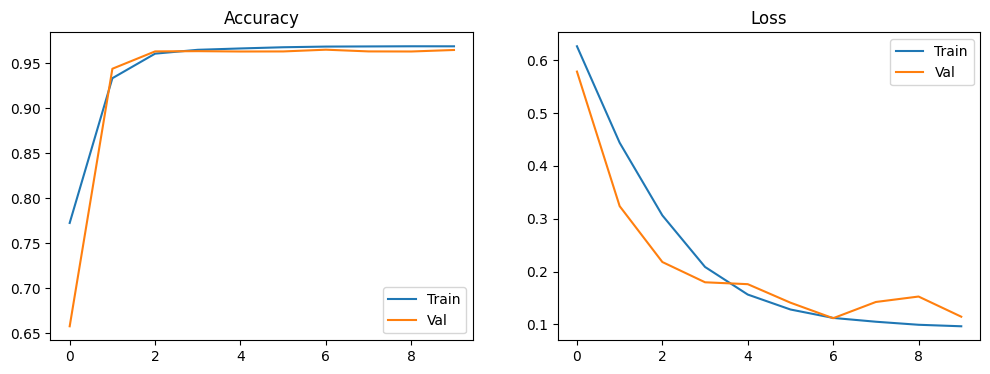

In [ ]:
# Cargar el mejor modelo guardado para asegurar la mejor versión
model.load_weights('mejor_modelo.h5')

# Gráficas los resultados del entrenamiento
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1); plt.plot(history.history['accuracy'], label='Train'); plt.plot(history.history['val_accuracy'], label='Val'); plt.legend(); plt.title('Accuracy')
plt.subplot(1, 2, 2); plt.plot(history.history['loss'], label='Train'); plt.plot(history.history['val_loss'], label='Val'); plt.legend(); plt.title('Loss')
plt.show()

#6. Inicializamos la etapa Test

🏥 INICIANDO AUDITORÍA FINAL DEL MODELO (TEST SET)...
7/7 ━━━━━━━━━━━━━━━━━━━━ 104s 15s/step - accuracy: 0.9729 - loss: 0.0926

🏆 RESULTADOS FINALES EN PACIENTES NUEVOS:
   - Pérdida (Loss): 0.1122
   - Precisión (Accuracy): 96.53%
1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step


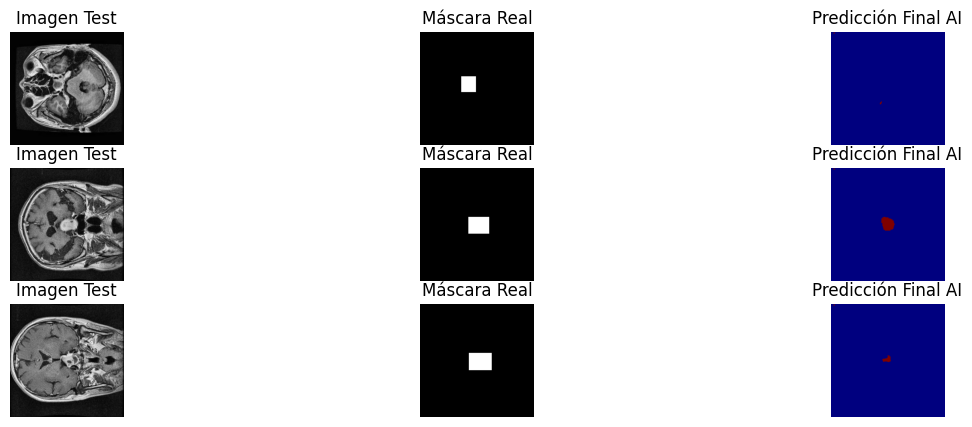

In [ ]:
print("INICIANDO AUDITORÍA FINAL DEL MODELO (TEST SET)")

# 1. Evaluación Cuantitativa (Dato duro para el reporte)
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\n🏆 RESULTADOS FINALES EN PACIENTES NUEVOS:")
print(f"   - Pérdida (Loss): {test_loss:.4f}")
print(f"   - Precisión (Accuracy): {test_acc:.2%}")

# 2. Evidencia Visual (Prueba de fuego)
def visualizar_test_final(model, dataset):
    plt.figure(figsize=(15, 5))
    for imgs, masks in dataset.take(1):
        preds = model.predict(imgs)
        # Mostramos 3 casos del set de prueba
        for i in range(3):
            plt.subplot(3, 3, i*3 + 1)
            plt.imshow(imgs[i])
            plt.title("Imagen Test")
            plt.axis('off')

            plt.subplot(3, 3, i*3 + 2)
            plt.imshow(masks[i].numpy().squeeze(), cmap='gray')
            plt.title("Máscara Real")
            plt.axis('off')

            plt.subplot(3, 3, i*3 + 3)
            plt.imshow(preds[i].squeeze() > 0.5, cmap='jet')
            plt.title("Predicción Final AI")
            plt.axis('off')
    plt.show()

visualizar_test_final(model, test_ds)

#7.Hacemos Pruebas con el modelo Pre entrenado

In [ ]:
# 1. Construyes el esqueleto (Arquitectura vacía)
model = build_unet_resnet50()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 2. Inyectas el conocimiento (Cargas el archivo .h5)
model.load_weights('mejor_modelo.h5')
print("✅ Pesos cargados exitosamente. El modelo está listo para predecir.")

# 3. Usas el modelo directamente
# model.predict(test_ds)

✅ Pesos cargados exitosamente. El modelo está listo para predecir.


🔄 Procesando visualización para 10 casos clínicos...


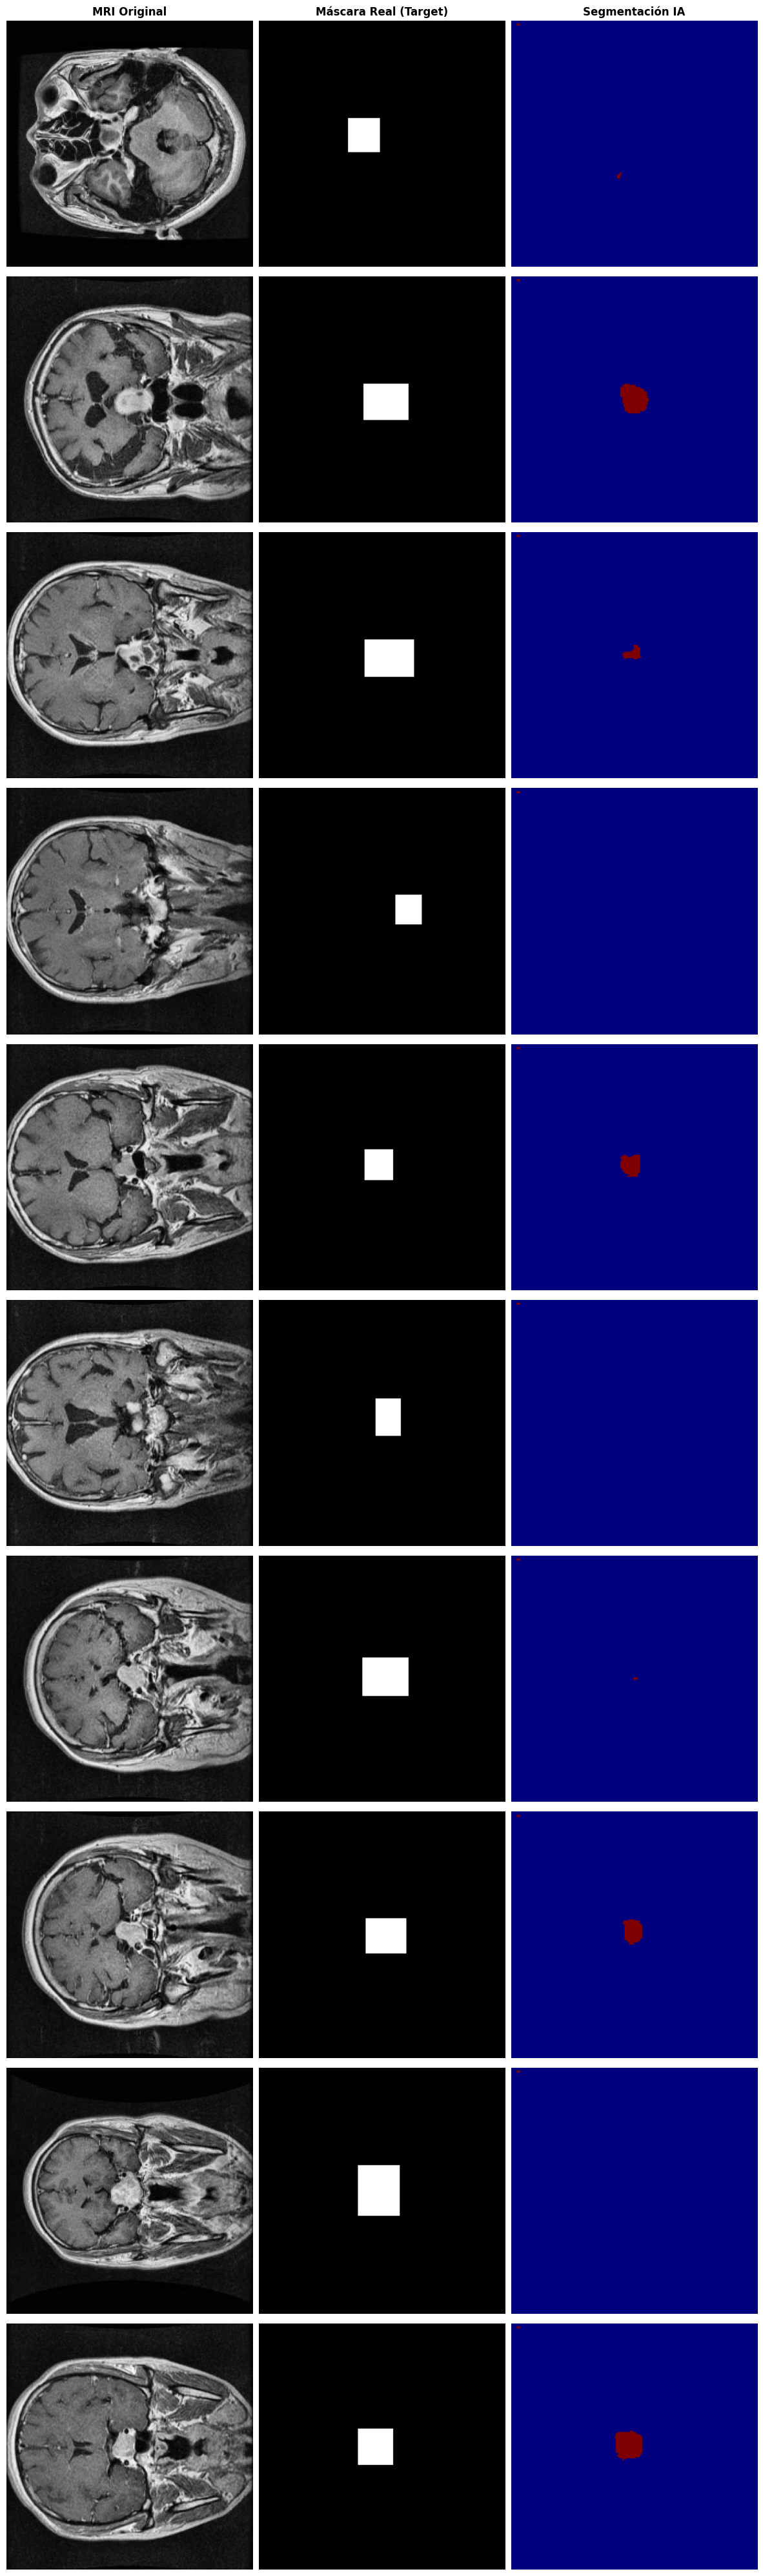

In [ ]:
def reporte_visual_masivo(model, dataset, num_muestras=10):
    """
    Genera una visualización extensiva de predicciones para el reporte final.
    Args:
        num_muestras: Cantidad de pacientes a evaluar (máximo 32 por batch).
    """
    print(f"🔄 Procesando visualización para {num_muestras} casos clínicos...")

    plt.figure(figsize=(12, 4 * num_muestras)) # Ajuste dinámico de altura

    # Tomamos un solo batch (que ya contiene 32 imágenes)
    for imgs, masks in dataset.take(1):
        preds = model.predict(imgs, verbose=0)

        for i in range(num_muestras):
            # Columna 1: Resonancia Original
            plt.subplot(num_muestras, 3, i*3 + 1)
            plt.imshow(imgs[i])
            if i == 0: plt.title("MRI Original", fontsize=12, fontweight='bold')
            plt.axis('off')

            # Columna 2: Ground Truth (Médico)
            plt.subplot(num_muestras, 3, i*3 + 2)
            plt.imshow(masks[i].numpy().squeeze(), cmap='gray')
            if i == 0: plt.title("Máscara Real (Target)", fontsize=12, fontweight='bold')
            plt.axis('off')

            # Columna 3: Predicción IA
            plt.subplot(num_muestras, 3, i*3 + 3)
            # Umbral de decisión 0.5
            plt.imshow(preds[i].squeeze() > 0.5, cmap='jet')
            if i == 0: plt.title("Segmentación IA", fontsize=12, fontweight='bold')
            plt.axis('off')

    plt.tight_layout()
    plt.show()

# Ejecutar para ver 10 casos aleatorios del Test Set
reporte_visual_masivo(model, test_ds, num_muestras=10)